<a href="https://colab.research.google.com/github/TommasoG85/Surplexity/blob/main/Surplexity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Qwen/Qwen2.5-1.5B... this may take a minute.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Fetching data from databases and APIs...
Attempting to fetch from Federal Register API (Open Legal Data)...
Legal data successfully fetched (Page 1).
Attempting to stream Nigerian Pidgin text (MasakhaNEWS)...
Nigerian Pidgin text successfully fetched from 'masakhane/masakhanews'.


Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Repo card metadata block was not found. Setting CardData to empty.


Calculating surplexity scores...

  DOCUMENTS ORDERED BY SURPLEXITY
1. Python Code      | Surplexity:       1.72
2. Simple Wiki      | Surplexity:       6.53
3. Synthetic (AI)   | Surplexity:      10.56
4. Finnegans Wake   | Surplexity:      31.62
5. Open Legal       | Surplexity:      32.50
6. Nigerian pidgin  | Surplexity:      68.00
7. Random Tokens    | Surplexity: 827,392.00

Complete. Displaying heatmaps...


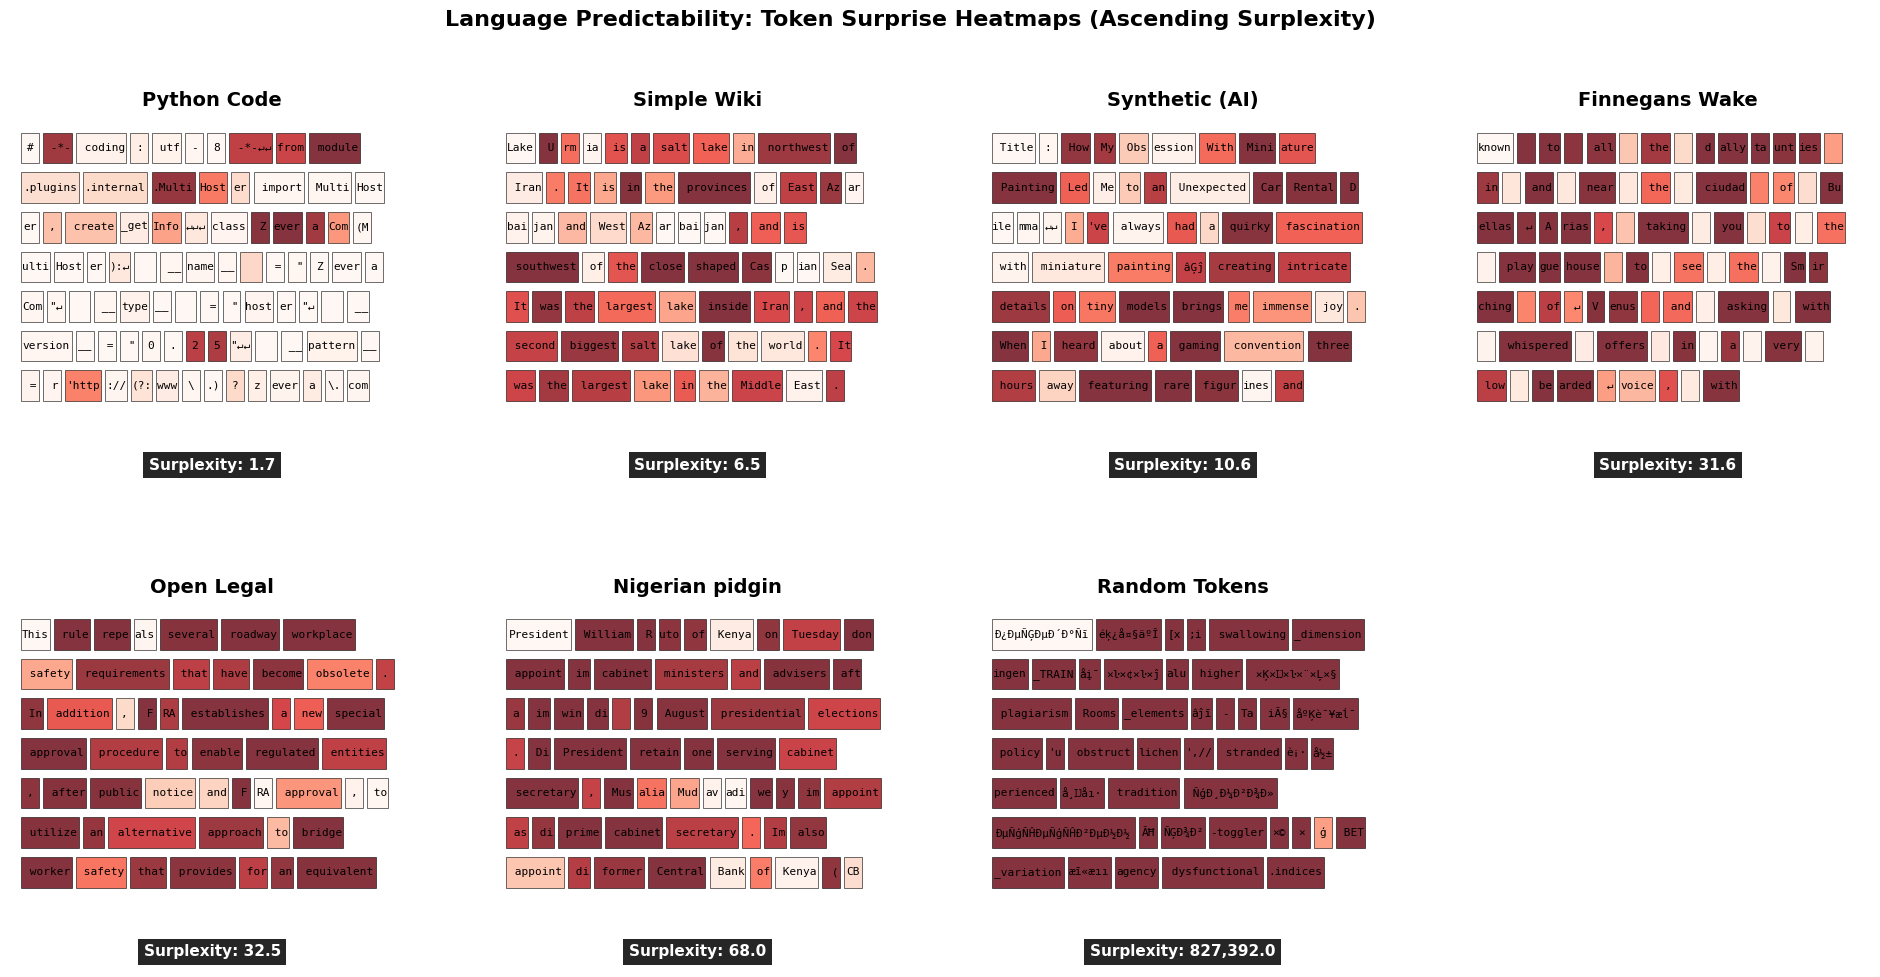

In [6]:
import random
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- 1. Setup ---
model_name = "Qwen/Qwen2.5-1.5B"

print(f"Loading {model_name}... this may take a minute.")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name, torch_dtype="auto", device_map="auto"
)
model.eval()

# --- 2. Data Fetching Functions ---


def get_wiki():
    url = "https://simple.wikipedia.org/api/rest_v1/page/random/summary"
    headers = {"User-Agent": "SurplexityBot/1.5"}
    try:
        r = requests.get(url, headers=headers, timeout=10)
        return r.json().get(
            "extract", "The atmosphere of Earth is a layer of gases."
        )
    except Exception:
        return "Wikipedia is a free online encyclopedia that anyone can edit."


def get_joyce():
    url = "https://archive.org/stream/finneganswake00joycuoft/finneganswake00joycuoft_djvu.txt"
    headers = {"User-Agent": "Mozilla/5.0"}
    try:
        response = requests.get(url, headers=headers, timeout=15)
        paragraphs = [
            p.strip()
            for p in response.text.split("\n\n")
            if len(p.strip()) > 150
        ]
        return random.choice(paragraphs)
    except Exception:
        return "riverrun, past Eve and Adam's, from swerve of shore to bend of bay..."


def get_ai_generated():
    try:
        ds = load_dataset(
            "HuggingFaceTB/cosmopedia-v2",
            name="cosmopedia-v2",
            split="train",
            streaming=True,
        )
        for item in ds.shuffle(buffer_size=100):
            if 300 < len(item["text"]) < 1200:
                return item["text"]
    except Exception:
        return "The concept of synthetic data involves creating information algorithmically."


def get_nigerian_pidgin():
    print("Attempting to stream Nigerian Pidgin text (MasakhaNEWS)...")
    dataset_options = [
        ("masakhane/masakhanews", "pcm", "text"),
        ("facebook/flores", "pcm_Latn", "sentence"),
    ]

    for ds_name, config, text_key in dataset_options:
        try:
            ds = load_dataset(ds_name, config, split="train", streaming=True)
            accumulated_text = []
            current_len = 0

            for item in ds.shuffle(buffer_size=50):
                content = (
                    item.get(text_key)
                    or item.get("headline")
                    or item.get("text")
                )
                if content and len(content.strip()) > 20:
                    clean_text = content.strip()
                    accumulated_text.append(clean_text)
                    current_len += len(clean_text) + 1

                    if current_len >= 300:
                        full_text = " ".join(accumulated_text)
                        print(
                            "Nigerian Pidgin text successfully fetched from"
                            f" '{ds_name}'."
                        )
                        return full_text[:1200]
        except Exception:
            continue

    print("Stream failed. Using Nigerian Pidgin fallback passage.")
    return (
        "People for different part of Nigeria dey cry say food item cost "
        "for market don high well well dis month. Plenty market woman "
        "explain say transport money and bad road na de main reason "
        "why price of garri, rice, and tomato dey jump every week. "
        "Gofment don promise say dem go quickly release grain from reserve "
        "to help reduce the suffer wey citizens dey face."
    )


def get_open_legal_data():
    print("Attempting to fetch from Federal Register API (Open Legal Data)...")
    random_page = random.randint(1, 10)
    url = f"https://www.federalregister.gov/api/v1/documents.json?per_page=20&page={random_page}"

    try:
        r = requests.get(url, timeout=10)
        docs = r.json().get("results", [])
        random.shuffle(docs)

        for doc in docs:
            abstract = doc.get("abstract", "")
            if abstract and 300 < len(abstract) < 1200:
                print(f"Legal data successfully fetched (Page {random_page}).")
                return abstract[:1200]
    except Exception as e:
        print(f"Federal Register API failed: {e}. Using fallback.")

    fallbacks = [
        "This final rule establishes the regulations for the implementation of"
        " the statutory requirements. The agency is amending its regulations"
        " to revise procedural standards under the open mandate.",
        "Notice is hereby given that the department intends to evaluate"
        " regulatory compliance standards pursuant to executive authorization."
        " Public comments and administrative records are open for review.",
        "The commission is issuing a directive updating operational oversight"
        " protocols. Affected entities must submit compliance statements within"
        " sixty days of publication.",
    ]
    return random.choice(fallbacks)


def get_code_snippet():
    try:
        ds = load_dataset(
            "codeparrot/codeparrot-clean-valid", split="train", streaming=True
        )
        for item in ds.shuffle(buffer_size=100):
            code = item["content"]
            if 300 < len(code) < 1500 and "def " in code:
                return code.strip()
    except Exception:
        return (
            "def calculate_loss(y_true, y_pred):\n    return"
            " np.mean(np.square(y_true - y_pred))"
        )


def get_random_sequence(length=85):
    vocab_size = tokenizer.vocab_size
    random_ids = [random.randint(0, vocab_size - 1) for _ in range(length)]
    return tokenizer.decode(random_ids)


# --- 3. Token Statistics & Heatmap ---


def get_token_stats(text, max_tokens=85):
    inputs = tokenizer(
        text, return_tensors="pt", truncation=True, max_length=max_tokens + 1
    )
    if inputs["input_ids"].shape[1] < 2:
        return ["Error"], [1.0], 0.0

    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
        logits = outputs.logits[:, :-1, :]
        target_ids = inputs["input_ids"][:, 1:]
        probs = torch.softmax(logits, dim=-1)
        token_probs = torch.gather(probs, 2, target_ids.unsqueeze(-1)).squeeze()
        loss = torch.nn.CrossEntropyLoss()(
            logits.view(-1, logits.size(-1)), target_ids.view(-1)
        )
        surplexity = torch.exp(loss).item()

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    raw_probs = (
        token_probs.tolist()
        if token_probs.dim() > 0
        else [token_probs.item()]
    )
    display_probs = [1.0] + raw_probs
    return tokens[:max_tokens], display_probs[:max_tokens], surplexity


def plot_heatmap(text, source_name, ax, token_limit=85):
    tokens, probs, surp = get_token_stats(text, max_tokens=token_limit)

    # Expanded horizontal boundary (0 to 180) to make boxes wider per row
    ax.set_xlim(0, 180)
    ax.set_ylim(0, 100)
    ax.axis("off")

    x_cursor, y_cursor = 5, 88
    line_height, char_width = 11.0, 3.2
    ax.set_title(f"{source_name}", fontweight="bold", fontsize=14, pad=10)

    for token, prob in zip(tokens, probs):
        clean_token = token.replace("Ġ", " ").replace("Ċ", "↵")
        token_len = max(len(clean_token) * char_width, 8.0)

        # Wrap line at X=172 (allows ~10-12 tokens per line)
        if x_cursor + token_len > 172:
            x_cursor = 5
            y_cursor -= line_height

        if y_cursor < 15:
            break

        color = plt.cm.Reds(1.0 - prob)
        rect = patches.Rectangle(
            (x_cursor, y_cursor),
            token_len,
            8.5,
            edgecolor="black",
            facecolor=color,
            alpha=0.8,
            linewidth=0.5,
        )
        ax.add_patch(rect)
        ax.text(
            x_cursor + (token_len / 2),
            y_cursor + 4.25,
            clean_token,
            ha="center",
            va="center",
            fontsize=8,
            family="monospace",
        )
        x_cursor += token_len + 1.8

    # Surplexity score centered at bottom
    ax.text(
        90,
        3,
        f"Surplexity: {surp:,.1f}",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color="white",
        bbox=dict(facecolor="black", alpha=0.85, edgecolor="none", pad=4),
    )


# --- 4. Execution ---

print("Fetching data from databases and APIs...")
raw_docs = [
    ("Simple Wiki", get_wiki()),
    ("Finnegans Wake", get_joyce()),
    ("Open Legal", get_open_legal_data()),
    ("Nigerian pidgin", get_nigerian_pidgin()),
    ("Synthetic (AI)", get_ai_generated()),
    ("Python Code", get_code_snippet()),
    ("Random Tokens", get_random_sequence()),
]

print("Calculating surplexity scores...")
docs = []
for name, text in raw_docs:
    _, _, surp = get_token_stats(text)
    docs.append((surp, name, text))

# Sort from lowest surplexity (most predictable) to highest (least predictable)
docs.sort(key=lambda item: item[0])

# Print ordered list to console
print("\n" + "=" * 40)
print("  DOCUMENTS ORDERED BY SURPLEXITY")
print("=" * 40)
for rank, (surp, name, _) in enumerate(docs, 1):
    print(f"{rank}. {name:<16} | Surplexity: {surp:>10,.2f}")
print("=" * 40 + "\n")

# Use a 2-row x 4-column layout to prevent narrow/slender squeezing
n_docs = len(docs)
n_cols = 4
n_rows = 2

fig = plt.figure(figsize=(24, 11))
gs = fig.add_gridspec(n_rows, n_cols, hspace=0.35, wspace=0.20)

for i, (surp, name, text) in enumerate(docs):
    row = i // n_cols
    col = i % n_cols
    ax = fig.add_subplot(gs[row, col])
    plot_heatmap(text, name, ax)

# Hide unused slot (8th subplot)
for i in range(n_docs, n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    ax = fig.add_subplot(gs[row, col])
    ax.axis("off")

plt.suptitle(
    "Language Predictability: Token Surprise Heatmaps (Ascending Surplexity)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

print("Complete. Displaying heatmaps...")
plt.show()

Loading Qwen/Qwen2.5-1.5B... this may take a minute.


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Fetching data from databases and APIs...
Attempting to fetch from Federal Register API (Open Legal Data)...
Legal data successfully fetched (Page 3).
Attempting to stream Nigerian Pidgin text (MasakhaNEWS)...
Nigerian Pidgin text successfully fetched from 'masakhane/masakhanews'.


Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Repo card metadata block was not found. Setting CardData to empty.


Calculating surplexity scores and sorting...

  DOCUMENTS ORDERED BY SURPLEXITY
1. Python Code      | Surplexity:       1.91
2. Synthetic (AI)   | Surplexity:       5.62
3. Simple Wiki      | Surplexity:       7.00
4. Open Legal       | Surplexity:       8.50
5. Finnegans Wake   | Surplexity:      32.50
6. Nigerian pidgin  | Surplexity:     153.00
7. Random Tokens    | Surplexity: 827,392.00

Complete. Displaying analysis...


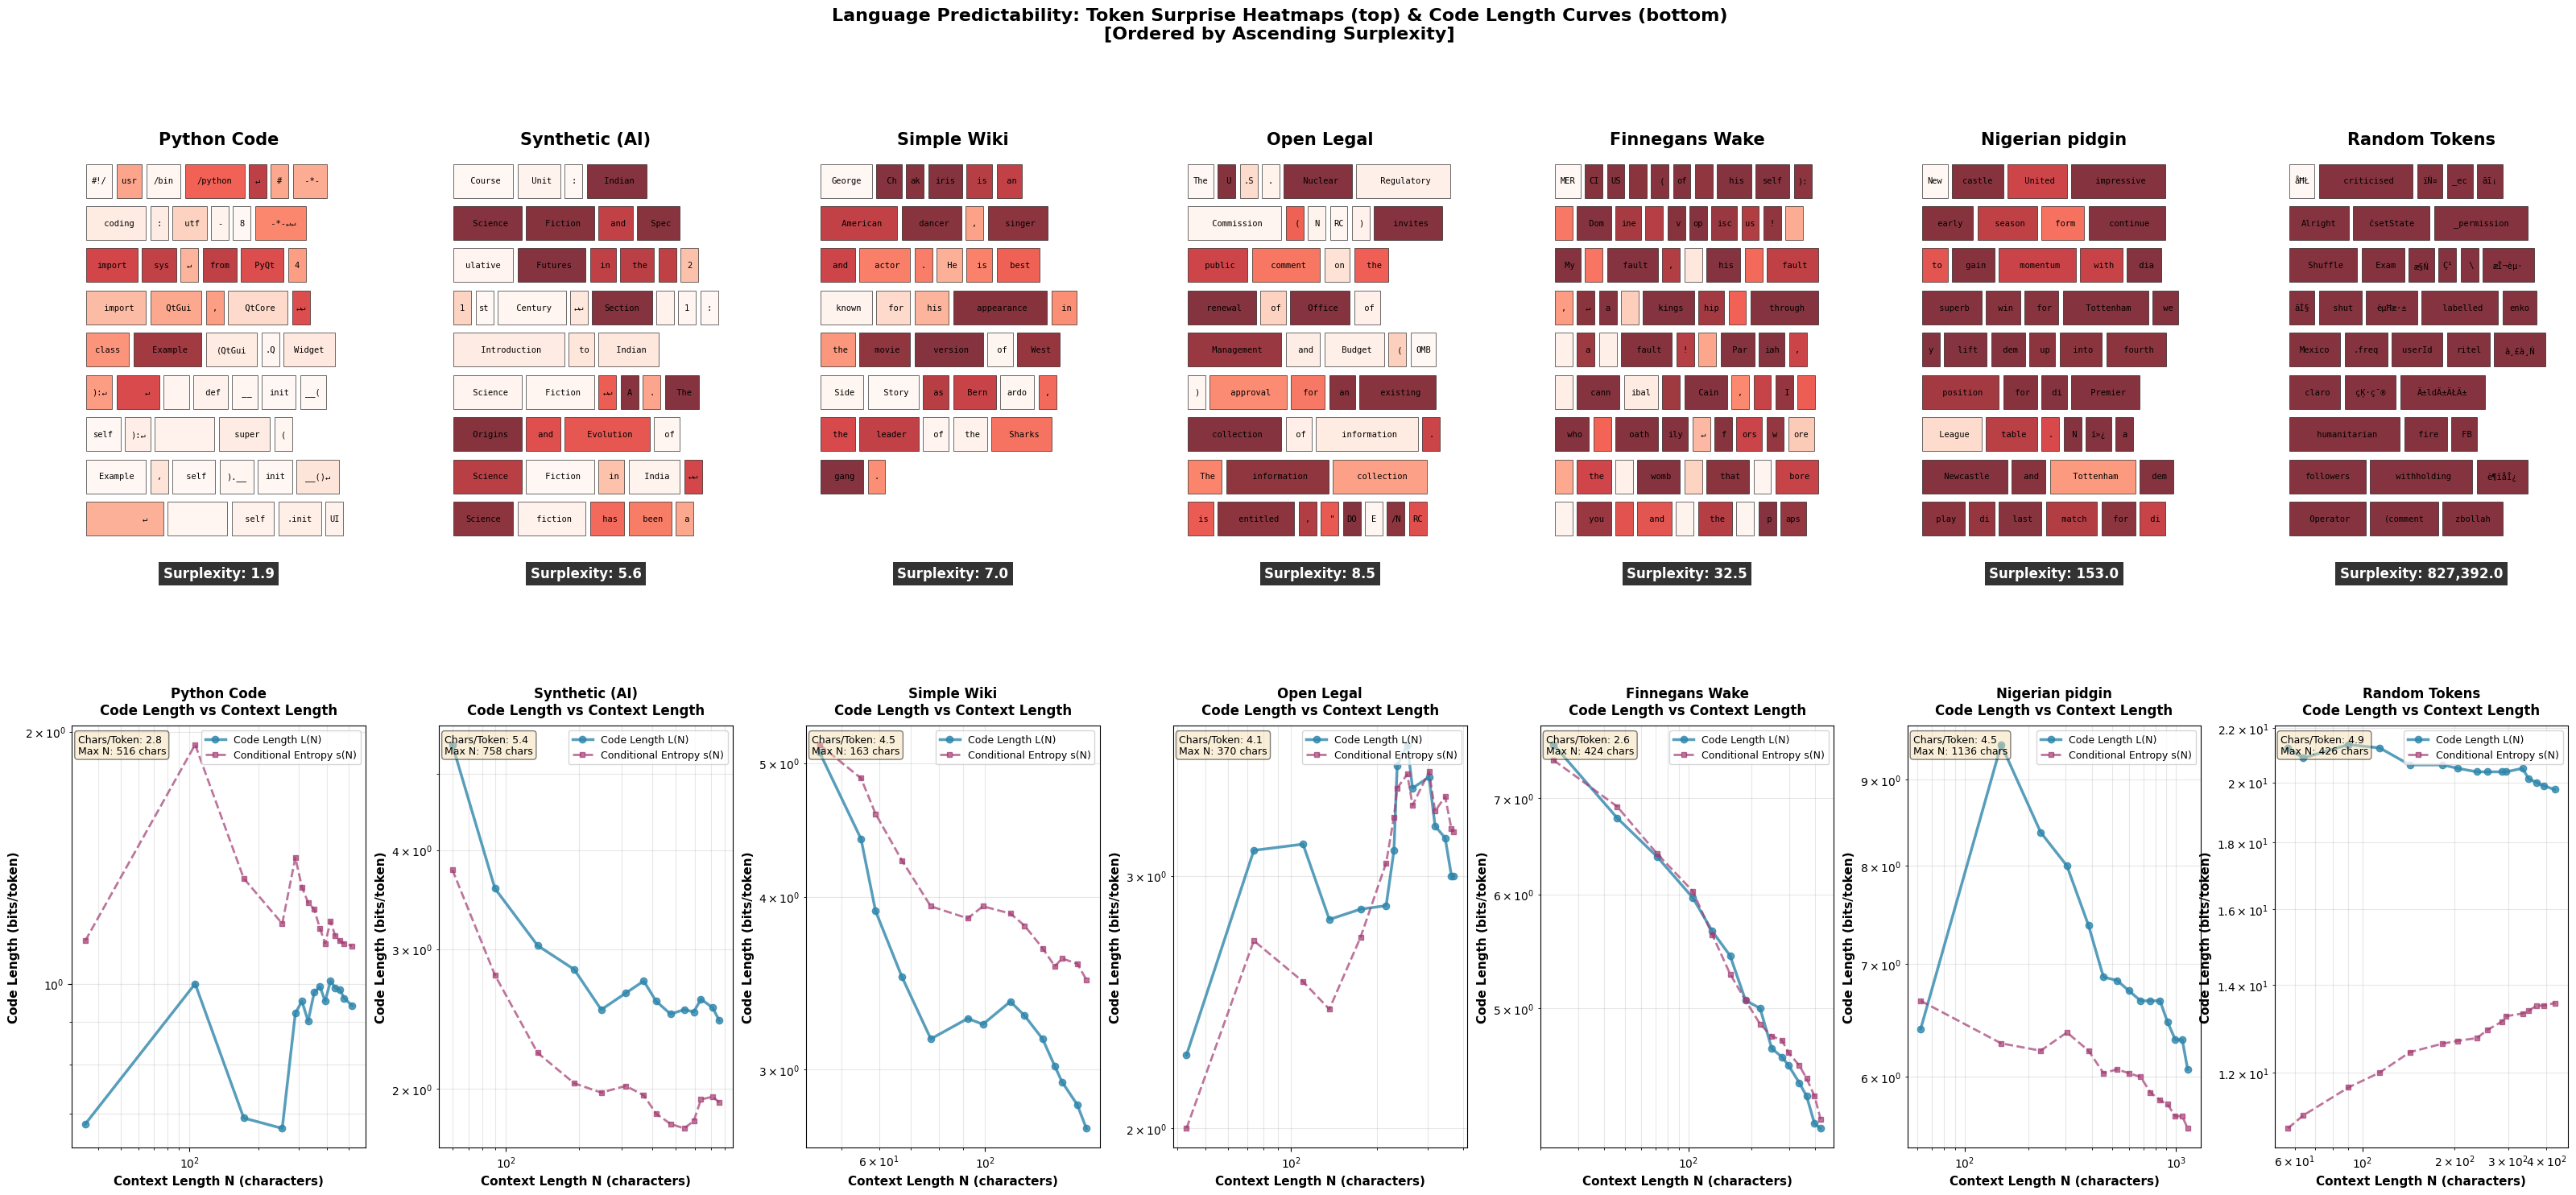

In [5]:
import torch
import requests
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- 1. Setup ---
model_name = "Qwen/Qwen2.5-1.5B"

print(f"Loading {model_name}... this may take a minute.")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
model.eval()

# --- 2. Data Fetching Functions ---

def get_wiki():
    url = "https://simple.wikipedia.org/api/rest_v1/page/random/summary"
    headers = {'User-Agent': 'SurplexityBot/1.5'}
    try:
        r = requests.get(url, headers=headers, timeout=10)
        return r.json().get('extract', "The atmosphere of Earth is a layer of gases.")
    except:
        return "Wikipedia is a free online encyclopedia that anyone can edit."

def get_joyce():
    url = "https://archive.org/stream/finneganswake00joycuoft/finneganswake00joycuoft_djvu.txt"
    headers = {'User-Agent': 'Mozilla/5.0'}
    try:
        response = requests.get(url, headers=headers, timeout=15)
        paragraphs = [p.strip() for p in response.text.split('\n\n') if len(p.strip()) > 150]
        return random.choice(paragraphs)
    except:
        return "riverrun, past Eve and Adam's, from swerve of shore to bend of bay..."

def get_ai_generated():
    try:
        ds = load_dataset("HuggingFaceTB/cosmopedia-v2", name="cosmopedia-v2", split="train", streaming=True)
        for item in ds.shuffle(buffer_size=100):
            if 300 < len(item['text']) < 1200: return item['text']
    except:
        return "The concept of synthetic data involves creating information algorithmically."

# REPLACED: Now hits the Federal Register API (Open Legal Database, no API key needed)
def get_open_legal_data():
    print("Attempting to fetch from Federal Register API (Open Legal Data)...")
    # Query a random page (1 to 10) for document variety
    random_page = random.randint(1, 10)
    url = f"https://www.federalregister.gov/api/v1/documents.json?per_page=20&page={random_page}"

    try:
        r = requests.get(url, timeout=10)
        docs = r.json().get('results', [])

        # Shuffle results so it doesn't always check index 0 first
        random.shuffle(docs)

        for doc in docs:
            abstract = doc.get('abstract', '')
            if abstract and 300 < len(abstract) < 1200:
                print(f"Legal data successfully fetched (Page {random_page}).")
                return abstract[:1200]
    except Exception as e:
        print(f"Federal Register API failed: {e}. Using fallback.")

    # Varied fallback options
    fallbacks = [
        "This final rule establishes the regulations for the implementation of the statutory requirements. "
        "The agency is amending its regulations to revise procedural standards under the open mandate.",

        "Notice is hereby given that the department intends to evaluate regulatory compliance standards "
        "pursuant to executive authorization. Public comments and administrative records are open for review.",

        "The commission is issuing a directive updating operational oversight protocols. "
        "Affected entities must submit compliance statements within sixty days of publication."
    ]
    return random.choice(fallbacks)

#pidgin
def get_nigerian_pidgin():
    print("Attempting to stream Nigerian Pidgin text (MasakhaNEWS)...")

    # Native Parquet-backed datasets (avoids legacy script errors)
    dataset_options = [
        ("masakhane/masakhanews", "pcm", "text"),
        ("facebook/flores", "pcm_Latn", "sentence")
    ]

    for ds_name, config, text_key in dataset_options:
        try:
            ds = load_dataset(ds_name, config, split="train", streaming=True)
            accumulated_text = []
            current_len = 0

            for item in ds.shuffle(buffer_size=50):
                content = item.get(text_key) or item.get("headline") or item.get("text")
                if content and len(content.strip()) > 20:
                    clean_text = content.strip()
                    accumulated_text.append(clean_text)
                    current_len += len(clean_text) + 1

                    # Accumulate sentences until reaching the 300+ character threshold
                    if current_len >= 300:
                        full_text = " ".join(accumulated_text)
                        print(f"Nigerian Pidgin text successfully fetched from '{ds_name}'.")
                        return full_text[:1200]

        except Exception:
            continue

    print("Stream failed. Using Nigerian Pidgin fallback passage.")
    return (
        "People for different part of Nigeria dey cry say food item cost "
        "for market don high well well dis month. Plenty market woman "
        "explain say transport money and bad road na de main reason "
        "why price of garri, rice, and tomato dey jump every week. "
        "Gofment don promise say dem go quickly release grain from reserve "
        "to help reduce the suffer wey citizens dey face."
    )

def get_code_snippet():
    try:
        ds = load_dataset("codeparrot/codeparrot-clean-valid", split="train", streaming=True)
        for item in ds.shuffle(buffer_size=100):
            code = item['content']
            if 300 < len(code) < 1500 and "def " in code:
                return code.strip()
    except:
        return "def calculate_loss(y_true, y_pred):\n    return np.mean(np.square(y_true - y_pred))"

def get_random_sequence(length=85):
    vocab_size = tokenizer.vocab_size
    random_ids = [random.randint(0, vocab_size - 1) for _ in range(length)]
    return tokenizer.decode(random_ids)

# --- 3. Code Length & Context Analysis ---

def get_code_length_curve_optimized(text, max_tokens=256):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_tokens)
    input_ids = inputs["input_ids"].to(model.device)

    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits[:, :-1, :]
        targets = input_ids[:, 1:]

        log_probs = torch.log_softmax(logits, dim=-1)
        token_log_probs = torch.gather(log_probs, 2, targets.unsqueeze(-1)).squeeze()
        all_bits = -token_log_probs / np.log(2)

        probs = torch.softmax(logits, dim=-1)
        all_entropy = -(probs * torch.log2(probs + 1e-10)).sum(dim=-1).squeeze()

    N_vals, L_vals, s_vals = [], [], []
    step = max(1, len(all_bits) // 15)
    for i in range(10, len(all_bits), step):
        N_vals.append(len(tokenizer.decode(input_ids[0, :i])))
        L_vals.append(all_bits[:i].mean().item())
        s_vals.append(all_entropy[:i].mean().item())

    return np.array(N_vals), np.array(L_vals), np.array(s_vals)

def plot_code_length_analysis(text, source_name, ax):
    try:
        N_vals, L_vals, s_vals = get_code_length_curve_optimized(text, max_tokens=256)

        if len(N_vals) < 2:
            ax.text(0.5, 0.5, "Insufficient data", ha='center', va='center',
                   transform=ax.transAxes, fontsize=12)
            return

        ax.loglog(N_vals, L_vals, 'o-', linewidth=2.5, markersize=6,
                 color='#2E86AB', label='Code Length L(N)', alpha=0.8)
        ax.loglog(N_vals, s_vals, 's--', linewidth=2, markersize=5,
                 color='#A23B72', label='Conditional Entropy s(N)', alpha=0.7)

        ax.set_xlabel('Context Length N (characters)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Code Length (bits/token)', fontsize=11, fontweight='bold')
        ax.set_title(f"{source_name}\nCode Length vs Context Length",
                    fontsize=12, fontweight='bold', pad=10)
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(fontsize=9, loc='upper right')

        char_per_token = len(text) / len(tokenizer.encode(text))
        stats_text = f"Chars/Token: {char_per_token:.1f}\nMax N: {N_vals[-1]:.0f} chars"
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
               fontsize=9, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    except Exception as e:
        print(f"Error in {source_name}: {e}")
        ax.text(0.5, 0.5, f"Error: {str(e)[:30]}", ha='center', va='center',
               transform=ax.transAxes, fontsize=10)

# --- 4. Token Statistics ---

def get_token_stats(text, max_tokens=85):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_tokens+1)
    if inputs["input_ids"].shape[1] < 2:
        return ["Error"], [1.0], 0.0

    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
        logits = outputs.logits[:, :-1, :]
        target_ids = inputs["input_ids"][:, 1:]
        probs = torch.softmax(logits, dim=-1)
        token_probs = torch.gather(probs, 2, target_ids.unsqueeze(-1)).squeeze()
        loss = torch.nn.CrossEntropyLoss()(logits.view(-1, logits.size(-1)), target_ids.view(-1))
        surplexity = torch.exp(loss).item()

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    raw_probs = token_probs.tolist() if token_probs.dim() > 0 else [token_probs.item()]
    display_probs = [1.0] + raw_probs
    return tokens[:max_tokens], display_probs[:max_tokens], surplexity

def plot_heatmap(text, source_name, ax, token_limit=85):
    tokens, probs, surp = get_token_stats(text, max_tokens=token_limit)
    ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis('off')
    x_cursor, y_cursor = 5, 90
    line_height, char_width = 10.0, 2.9
    ax.set_title(f"{source_name}", fontweight='bold', fontsize=15, pad=10)
    ax.text(50, 0, f"Surplexity: {surp:,.1f}", ha='center', fontsize=12, fontweight='bold',
            color='white', bbox=dict(facecolor='black', alpha=0.8, edgecolor='none'))

    for token, prob in zip(tokens, probs):
        clean_token = token.replace('Ġ', ' ').replace('Ċ', '↵')
        token_len = max(len(clean_token) * char_width, 6.0)
        if x_cursor + token_len > 95:
            x_cursor, y_cursor = 5, y_cursor - line_height
        if y_cursor < 10: break

        color = plt.cm.Reds(1.0 - prob)
        rect = patches.Rectangle((x_cursor, y_cursor), token_len, 8,
                                 edgecolor='black', facecolor=color, alpha=0.8, linewidth=0.5)
        ax.add_patch(rect)
        ax.text(x_cursor + (token_len/2), y_cursor + 4, clean_token,
                ha='center', va='center', fontsize=7.5, family='monospace')
        x_cursor += token_len + 1.5

# --- 5. Execution ---

print("Fetching data from databases and APIs...")
raw_docs = [
    ("Simple Wiki", get_wiki()),
    ("Finnegans Wake", get_joyce()),
    ("Open Legal", get_open_legal_data()),
    ("Nigerian pidgin", get_nigerian_pidgin()),
    ("Synthetic (AI)", get_ai_generated()),
    ("Python Code", get_code_snippet()),
    ("Random Tokens", get_random_sequence())
]

print("Calculating surplexity scores and sorting...")
docs = []
for name, text in raw_docs:
    _, _, surp = get_token_stats(text)
    docs.append((surp, name, text))

# Sort from lowest surplexity (most predictable) to highest (least predictable)
docs.sort(key=lambda item: item[0])

# Print ordered list to console
print("\n" + "=" * 40)
print("  DOCUMENTS ORDERED BY SURPLEXITY")
print("=" * 40)
for rank, (surp, name, _) in enumerate(docs, 1):
    print(f"{rank}. {name:<16} | Surplexity: {surp:>10,.2f}")
print("=" * 40 + "\n")

# Dual-row visualization (Heatmaps top, Code Length Curves bottom)
fig = plt.figure(figsize=(40, 16))
gs = fig.add_gridspec(2, len(docs), hspace=0.35, wspace=0.25)

for i, (surp, name, text) in enumerate(docs):
    # Heatmap (top row)
    ax_heatmap = fig.add_subplot(gs[0, i])
    plot_heatmap(text, name, ax_heatmap)

    # Code length curve (bottom row)
    ax_curve = fig.add_subplot(gs[1, i])
    plot_code_length_analysis(text, name, ax_curve)

plt.suptitle("Language Predictability: Token Surprise Heatmaps (top) & Code Length Curves (bottom)\n[Ordered by Ascending Surplexity]",
             fontsize=16, fontweight='bold', y=0.995)

print("Complete. Displaying analysis...")
plt.show()